In [38]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
# Custom Dataset
data = {
    'loan_id': [101, 102, 103, 104],
    'application_date': ['11/02/23', '05/22/24', '12/06/23', '04/14/24'], # MM/DD/YY
    'disbursement_date': ['13 november, 2026', '01 january, 2025', '15 august, 2024', '31 december, 2025']
}
df = pd.DataFrame(data)
df

,loan_id,application_date,disbursement_date
0,101,11/02/23,"13 november, 2026"
1,102,05/22/24,"01 january, 2025"
2,103,12/06/23,"15 august, 2024"
3,104,04/14/24,"31 december, 2025"


## Data Parsing

In [40]:
'''
    Date Parsing: ডেটাসেটে তারিখগুলো string হিসেবে থাকে। Machine Learning মডেল টেক্সট থেকে সময় বা ট্রেন্ড বুঝতে পারে না। Date Parsing হলো সেই টেক্সটকে ভেঙে একটি গাণিতিক datetime অবজেক্টে কনভার্ট করা। এর জন্য আমরা pd.to_datetime() ব্যবহার করি এবং বলে দিই তারিখের কোথায় মাস, কোথায় দিন আর কোথায় বছর আছে (format="%m/%d/%y").
    
    Convert Date Columns to Datetime (date parsing)
    String-কে proper date-এ কনভার্ট করতে আমরা Pandas-এর pd.to_datetime() ফাংশন ব্যবহার করি। এর জন্য format প্যারামিটার দিয়ে Python-কে বলে দিতে হয় string-এর ঠিক কোথায় মাস, দিন এবং বছর আছে।

    Format Directives:
        %d: দিন (01-31)
        %m: মাস সংখ্যায় (01-12)
        %y: ২-ডিজিটের বছর (যেমন 23)
        %Y: ৪-ডিজিটের বছর (যেমন 2023)
        %B: মাসের সম্পূর্ণ নাম (যেমন november)


    Practical ML Implication: Data Preprocessing ধাপে Date Parsing করা অত্যন্ত জরুরি। এটি করার পর Feature Engineering ধাপে আমরা এই তারিখ থেকে নতুন feature বানাতে পারি। যেমন: "দিনটি কি ছুটির দিন ছিল?", "মাসের কোন সপ্তাহে ঘটনাটি ঘটেছে?", বা "অ্যাকাউন্ট খোলার পর কত দিন পার হয়েছে?"—যা মডেলের প্রেডিকশন পাওয়ার অনেক বাড়িয়ে দেয়।

'''

pass

In [41]:
# checking the datatype of application_date column
print(df['application_date'].dtype)

str


In [42]:
# Numerical string parsing (MM/DD/YY)
df['app_date_parsed'] = pd.to_datetime(df['application_date'], format="%m/%d/%y")

print(df['app_date_parsed'].dtype)

datetime64[us]


In [43]:
# Text-based string parsing ("13 november, 2026")
# এখানে স্পেস এবং কমা (,) হুবহু string-এর মতো করে format-এ দিতে হবে

df['disburse_date_parsed'] = pd.to_datetime(df['disbursement_date'], format="%d %B, %Y")

print(df['disburse_date_parsed'].dtype)

datetime64[us]


In [44]:
# Select the Day of the Month (ডকুমেন্টেশন টপিক)
#ডেটা datetime64 এ কনভার্ট হওয়ার পর আমরা .dt accessor ব্যবহার করে খুব সহজেই নির্দিষ্ট feature extract করতে পারি।

# দিন আলাদা করা
df['app_day'] = df['app_date_parsed'].dt.day

print(df['app_day'])


0     2
1    22
2     6
3    14
Name: app_day, dtype: int32


In [45]:
# একইভাবে মাস বা বছর আলাদা করা যায়
df['app_month'] = df['app_date_parsed'].dt.month

print(df['app_month'])

0    11
1     5
2    12
3     4
Name: app_month, dtype: int32


In [46]:
df

,loan_id,application_date,disbursement_date,app_date_parsed,disburse_date_parsed,app_day,app_month
0,101,11/02/23,"13 november, 2026",2023-11-02,2026-11-13,2,11
1,102,05/22/24,"01 january, 2025",2024-05-22,2025-01-01,22,5
2,103,12/06/23,"15 august, 2024",2023-12-06,2024-08-15,6,12
3,104,04/14/24,"31 december, 2025",2024-04-14,2025-12-31,14,4


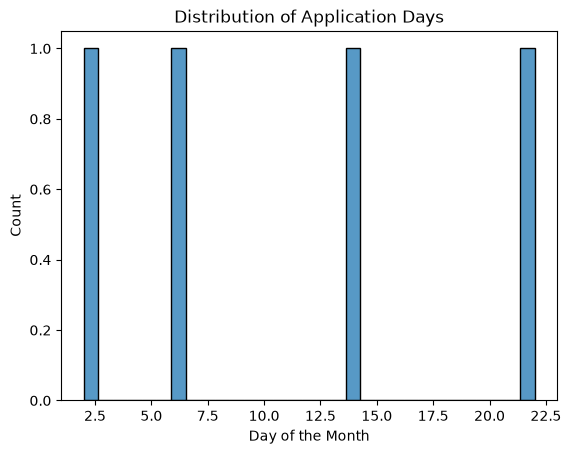

In [47]:
# Date parsing-এর সময় সবচেয়ে বড় রিস্ক হলো মাস এবং দিন উল্টে ফেলা। এটি চেক করার জন্য আমরা দিনগুলোর একটি histogram প্লট করতে পারি। jodi day-এর distribution 1-31 এর মধ্যে না থাকে, তবে আমরা বুঝতে পারব যে কোন না কোন জায়গায় মাস এবং দিন উল্টে গেছে।

sns.histplot(df['app_day'].dropna(), bins=31, kde=False, )
plt.title("Distribution of Application Days")
plt.xlabel("Day of the Month")
plt.show()

## Time Delta

In [51]:
'''
    Time Delta (সময়ের পার্থক্য বের করা)
    এটি Date/Time ডেটার ক্ষেত্রে সবচেয়ে বেশি ব্যবহৃত টেকনিক। তোমার কাছে যদি দুটি তারিখ থাকে, তবে তাদের মধ্যকার পার্থক্য (দিন, মাস বা বছর হিসেবে) বের করতে পারাটা অত্যন্ত জরুরি।

    উদাহরণ: ইউজারের loan_disbursement_date থেকে application_date বিয়োগ করে দেখা যে লোনটি প্রসেস হতে কত দিন সময় লেগেছে। এই পার্থক্যটি একটি numerical feature হিসেবে কাজ করে, যা মডেল সরাসরি ব্যবহার করতে পারে।

'''
pass

In [49]:
# etar jonne aager dataset tai use korbo

df

,loan_id,application_date,disbursement_date,app_date_parsed,disburse_date_parsed,app_day,app_month
0,101,11/02/23,"13 november, 2026",2023-11-02,2026-11-13,2,11
1,102,05/22/24,"01 january, 2025",2024-05-22,2025-01-01,22,5
2,103,12/06/23,"15 august, 2024",2023-12-06,2024-08-15,6,12
3,104,04/14/24,"31 december, 2025",2024-04-14,2025-12-31,14,4


In [50]:
# ১. সরাসরি বিয়োগ করা (এটি timedelta object রিটার্ন করবে)
df['time_difference'] = df['disburse_date_parsed'] - df['app_date_parsed']

# ২. Machine Learning-এর জন্য Integer বা Number-এ কনভার্ট করা
# .dt.days ব্যবহার করে আমরা শুধু 'দিন' সংখ্যাটি আলাদা করে নিচ্ছি
df['processing_days'] = (df['disburse_date_parsed'] - df['app_date_parsed']).dt.days

print(df[['loan_id', 'time_difference', 'processing_days']])

   loan_id time_difference  processing_days
0      101       1107 days             1107
1      102        224 days              224
2      103        253 days              253
3      104        626 days              626
